# Predicting At-Risk Students Using Machine Learning

## AAI-510: Machine Learning Fundamentals and Applications

### Final Project

**Team Members:**
* Ashley Figueroa
* Saman Tavasoli
* Jackson Kenyon

---

### Links & Resources

**Our GitHub Repository:**
https://github.com/SamTavasoli/AAI-510-At-Risk-Student-Prediction

**Dataset Source (Kaggle):**
https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset

---

### Project Overview

For our final project, we set out to build a machine learning model that can flag students who might be academically "at risk" based on their demographics, behaviors, and study habits. The goal is simple: if schools can identify these students early, they can step in with tutoring or counseling before things get too far off track.

**A quick note on how we built this:** One major decision we made early on was to completely remove GPA from our predictive models. While it's easy to predict a student will fail if they already have a terrible GPA, using it causes target leakage and defeats the whole purpose of an *early-warning* system. Because of this, we only kept GPA around for our initial data exploration.

In this notebook, we test and compare a few different supervised learning algorithms (Decision Tree, Random Forest, and XGBoost). We will walk through our feature engineering, evaluate the models, and wrap up with some practical recommendations on how a school could actually deploy this tool (along with a few limitations we noticed along the way).

---

### How to Run Our Code (Reproducibility)

If you are reviewing this and want to run the notebook yourself:

1. Download the dataset from the Kaggle link above.
2. Make sure the dataset file is saved in the exact same directory as this notebook.
3. Ensure you have the required Python libraries installed (we used Scikit-learn, XGBoost, Pandas, NumPy, Matplotlib, and Seaborn).
4. Run all the cells in order from top to bottom.

---

# 1. Project Setup

In this first cell, we are importing all the Python libraries we will need for the project. We rely heavily on standard data science tools like Pandas and NumPy for cleaning up the data, Matplotlib and Seaborn for our visualizations, and Scikit-Learn along with XGBoost for building, tuning, and evaluating our machine learning models.

In [1]:
# Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


import warnings
warnings.filterwarnings("ignore")

# 2. Business Understanding

## Why Are We Doing This? (Business Need)
Schools and educational institutions only have so many counselors and tutoring resources to go around. Because of this, we need a reliable way to flag students who might need extra help *before* their academic struggles become too severe.

## Our Objective
Our goal is to build a machine learning model that predicts whether a student is academically "at risk." To make this realistic, we are only training the model on information that a school could actually track and act on, such as:
* Attendance
* Weekly study time
* Tutoring participation
* Parental support
* Extracurricular engagement
* Demographic context

## How This Model Should Be Used
We designed this model to help counselors figure out where to focus their time and resources. It is meant to act as a support tool to guide human review, and should absolutely not be used to automatically label, penalize, or make irreversible decisions about a student.

## Prediction Timeline
We envision this as an early-warning system that a school could run on a regular schedule, like weekly or mid-semester. Because of this, we made sure the model only relies on information that would actually be available at that specific point in the academic year.

## Defining "At Risk"
The source dataset groups students into five grade categories. For the purposes of our project, we decided to define "At Risk" as any student falling into categories 3 or 4 (D and F grades), since those are the grades that typically trigger an academic intervention.

Here is how we mapped it:

| GradeClass | Approximate Interpretation | Project Target  |
| ---------: | -------------------------- | --------------- |
|          0 | A                          | Not At Risk (0) |
|          1 | B                          | Not At Risk (0) |
|          2 | C                          | Not At Risk (0) |
|          3 | D                          | At Risk (1)     |
|          4 | F                          | At Risk (1)     |



## How We Evaluate Success
For this specific business problem, our team cares a lot about minimizing False Negatives. A false negative means a struggling student slips through the cracks and misses out on support. Because of this, we aren't just looking at overall Accuracy. Instead, our evaluation emphasizes:
* Recall for the At Risk class
* Precision for the At Risk class
* F1-score
* ROC-AUC
* Confusion Matrix

# 3. Dataset Loading

In [2]:
# Load the dataset

df = pd.read_csv("Student_performance_data _.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(2392, 15)

First 5 Rows:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


### Step 3 Results (Dataset Loading)

We loaded the data! We are working with **2,392 student records** and **15 different columns** (variables). These columns cover a good mix of information, like the students' backgrounds, their study habits, and how they are doing in school.

At first, this looks like exactly the kind of information we need to start figuring out which students might need extra help.

Later, we are going to dig a bit deeper into the numbers and check the overall quality of the data (like looking for missing or weird values) before we actually start building our machine learning model.


# 4. Data Understanding

Before we jump into the heavy machine learning, we need to understand what information we actually have to work with.

Our dataset has one row for each student. The columns give us a great mix of details about their background, how often they show up to class, their study habits, parental support, and overall school performance.

In this section, we are going to look at the overall structure of the data, the types of numbers and categories we are dealing with, and some basic summary stats. We also put together a quick data dictionary to explain exactly what each column means for our project.

**A quick heads-up on a couple of columns:** We have to be extra careful with the `GPA` and `GradeClass` variables. Like we mentioned earlier, these are great for exploring the data and helping us define who is actually "at risk." However, we have to drop them before we train our predictive model. If we leave them in, it would be like giving the model the answers to the test before it even takes it (which is known as target leakage)!


In [3]:
# Explore the dataset

print("Dataset Info:\n")
df.info()

print("\nSummary Statistics:")
display(df.describe(include="all").T)

print("\nUnique Values:")
for column in df.columns:
    if df[column].nunique() <= 10:
        print(f"{column}: {sorted(df[column].dropna().unique().tolist())}")

print("\nMissing Values:")
display(df.isnull().sum())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB

Summary 

,count,mean,std,min,25%,50%,75%,max
StudentID,2392.0,2196.500000,690.655244,1001.000000,1598.750000,2196.500000,2794.250000,3392.000000
Age,2392.0,16.468645,1.123798,15.000000,15.000000,16.000000,17.000000,18.000000
Gender,2392.0,0.510870,0.499986,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2392.0,0.877508,1.028476,0.000000,0.000000,0.000000,2.000000,3.000000
ParentalEducation,2392.0,1.746237,1.000411,0.000000,1.000000,2.000000,2.000000,4.000000
StudyTimeWeekly,2392.0,9.771992,5.652774,0.001057,5.043079,9.705363,14.408410,19.978094
Absences,2392.0,14.541388,8.467417,0.000000,7.000000,15.000000,22.000000,29.000000
Tutoring,2392.0,0.301421,0.458971,0.000000,0.000000,0.000000,1.000000,1.000000
ParentalSupport,2392.0,2.122074,1.122813,0.000000,1.000000,2.000000,3.000000,4.000000
Extracurricular,2392.0,0.383361,0.486307,0.000000,0.000000,0.000000,1.000000,1.000000



Unique Values:
Age: [15, 16, 17, 18]
Gender: [0, 1]
Ethnicity: [0, 1, 2, 3]
ParentalEducation: [0, 1, 2, 3, 4]
Tutoring: [0, 1]
ParentalSupport: [0, 1, 2, 3, 4]
Extracurricular: [0, 1]
Sports: [0, 1]
Music: [0, 1]
Volunteering: [0, 1]
GradeClass: [0.0, 1.0, 2.0, 3.0, 4.0]

Missing Values:


,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


### Step 4 Results (Data Understanding)

After looking through the dataset, we confirmed we are working with **2,392 students** and **15 columns** of information. The best news is that there is absolutely no missing data, which means we don't have to waste any time filling in blanks or dropping rows!

The information is a good mix of numbers and categories. The number columns track Age, weekly study hours, Absences, and GPA. The rest of the columns are categories that tell us about the student's background, how much support they get at home, and if they do things like tutoring, sports, music, or volunteering.

Just looking at the averages, here is a quick snapshot of the students in our data:
* They are between **15 and 18 years old** (the average age is about 16.5).
* They study around **9.8 hours per week**.
* They have missed around **14.5 days** of school.
* Their GPAs are all over the board, ranging from **0.0 to a perfect 4.0**.

We also double-checked all the category columns to make sure the labels made sense, and everything looks perfectly fine. There are no weird inputs or typos to fix.

Basically, the data is incredibly clean and ready for us to start exploring!


# 5. Target Variable Creation


In the original data, the **GradeClass** column gives students letter grades from A to F. But since our main goal is just to figure out which students need extra support, we decided to simplify this into a straightforward "Yes or No" problem.

We created a new column with a very simple rule:
* If a student is earning a **D or an F**, we label them as **At Risk (1)**.
* If they are earning an **A, B, or C**, we label them as **Not At Risk (0)**.

Basically, grouping the students this way makes it much easier to train our machine learning models, and it lines up perfectly with our goal of building an early-warning system.


In [4]:
# Create the target variable

df = df.copy()

# D and F grades are considered At Risk
df["AtRisk"] = df["GradeClass"].isin([3.0, 4.0]).astype(int)

grade_mapping = {
    0.0: "A",
    1.0: "B",
    2.0: "C",
    3.0: "D",
    4.0: "F"
}

df["GradeClassLabel"] = df["GradeClass"].map(grade_mapping)

counts = df["AtRisk"].value_counts().sort_index()
percentages = df["AtRisk"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": counts,
    "Percentage": percentages.round(2)
})

target_summary.index = ["Not At Risk", "At Risk"]

display(target_summary)

,Count,Percentage
Not At Risk,767,32.07
At Risk,1625,67.93


### Step 5 Results (Target Variable Creation)

After applying our new rule, we found that **1,625 students (about 68%)** fall into the **At Risk** category, while **767 students (about 32%)** are **Not At Risk**.

While the two groups aren't perfectly equal, the gap isn't huge. Because of that, we decided not to mess with any advanced resampling techniques right now. We are just going to build our initial models using the data exactly as it is.

Since our main goal is to make sure struggling students don't slip through the cracks, we know we can't just rely on standard "accuracy" to tell us if our model is doing a good job. Instead, we are going to focus heavily on metrics like **Recall**, **Precision**, **F1-Score**, and **ROC-AUC**.

Basically, our target variable is set up and we are ready to start exploring the relationships in the data!


# 6. Data Quality Assessment

* 6.1 Checking for Missing or Duplicate Data
* 6.2 Making Sure the Values Make Sense

Before we start making predictions, we need to make sure the data we are feeding into our model is actually good.

In this step, we are double-checking a few things:
* Are there any blanks or missing values?
* Did any student accidentally get counted twice?
* Do the data types make sense (like making sure 'Age' is actually saved as a number)?
* Are the values realistic (for example, making sure no one has a GPA of 5.0 or negative absences)?

Basically, we just want to catch any weird data issues right now so they don't mess up our models later.


In [5]:
# Data quality checks

quality_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing": df.isna().sum(),
    "Unique Values": df.nunique()
})

display(quality_summary)

print(f"Total Missing Values: {df.isna().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Duplicate StudentIDs: {df['StudentID'].duplicated().sum()}")

,Data Type,Missing,Unique Values
StudentID,int64,0,2392
Age,int64,0,4
Gender,int64,0,2
Ethnicity,int64,0,4
ParentalEducation,int64,0,5
StudyTimeWeekly,float64,0,2392
Absences,int64,0,30
Tutoring,int64,0,2
ParentalSupport,int64,0,5
Extracurricular,int64,0,2


Total Missing Values: 0
Duplicate Rows: 0
Duplicate StudentIDs: 0


### Step 6.1 Results (Checking for Missing or Duplicate Data)

When we checked the data, the first thing we noticed was that there are absolutely no missing values. This was good because it means we don't have to spend time filling in blanks or dropping rows.

We also double-checked for duplicates. We didn't find any copy-pasted rows or repeated Student IDs, so we know for sure that every single row represents one unique student.

Next, we counted the unique values in our category columns just to make sure they made sense. Everything lined up exactly how we expected:
* The Yes/No columns only have two options.
* Things like Parental Education and Parental Support have exactly five levels.
* Ethnicity has four categories.
* Our grade columns perfectly match the five standard letter grades.

Basically, the dataset is super clean, consistent, and we didn't find any major issues that need fixing.


## 6.2 Making Sure the Values Make Sense

Now that we know we don't have any missing or duplicate rows, our next step is to make sure the actual information inside the columns is reasonable.

We are going to check if our number columns fall into expected ranges (for example, making sure no student has a negative age or a GPA over 4.0). We will also double-check our Yes/No columns to make sure there are no weird, unexpected inputs.

Basically, we just want to catch any obvious typos or data entry mistakes before we move on to the fun part of exploring the data!

In [6]:
# Validate ranges and categories

validation_checks = {
    "Age is between 15 and 18": df["Age"].between(15, 18).all(),
    "StudyTimeWeekly is between 0 and 20": df["StudyTimeWeekly"].between(0, 20).all(),
    "Absences is between 0 and 29": df["Absences"].between(0, 29).all(),
    "GPA is between 0 and 4": df["GPA"].between(0, 4).all(),
    "GradeClass uses values 0-4": set(df["GradeClass"].dropna()).issubset({0, 1, 2, 3, 4}),
    "Gender is binary": set(df["Gender"].dropna()).issubset({0, 1}),
    "Tutoring is binary": set(df["Tutoring"].dropna()).issubset({0, 1}),
    "Extracurricular is binary": set(df["Extracurricular"].dropna()).issubset({0, 1}),
    "Sports is binary": set(df["Sports"].dropna()).issubset({0, 1}),
    "Music is binary": set(df["Music"].dropna()).issubset({0, 1}),
    "Volunteering is binary": set(df["Volunteering"].dropna()).issubset({0, 1})
}

validation_df = pd.DataFrame.from_dict(
    validation_checks,
    orient="index",
    columns=["Passed"]
)

display(validation_df)

assert validation_df["Passed"].all(), "One or more validation checks failed."

print("All validation checks passed.")

,Passed
Age is between 15 and 18,True
StudyTimeWeekly is between 0 and 20,True
Absences is between 0 and 29,True
GPA is between 0 and 4,True
GradeClass uses values 0-4,True
Gender is binary,True
Tutoring is binary,True
Extracurricular is binary,True
Sports is binary,True
Music is binary,True


All validation checks passed.


### Step 6.2 Results (Checking the Values)

All of our data checks passed!

We looked through the numbers and everything makes perfect sense. The students are all between 15 and 18 years old, their study hours and absences look normal, and the GPAs are exactly where they should be (between 0.0 and 4.0). Our grade categories also match up perfectly.

For the Yes/No columns—like Tutoring, Sports, Music, and Volunteering—we only found 0s and 1s. There were no unexpected numbers or typos mixed in.

Basically, we didn't find a single invalid value or data issue. The dataset is super clean and completely ready for us to start exploring and building our model.


### Step 6 Final Conclusion (Data Quality Assessment)


Basically, our data passed all the tests.

We didn't find any empty blanks, there were no duplicate students, and all the numbers and categories make perfect sense. Because the dataset is already in such great shape, we don't have to spend any extra time cleaning or fixing things.

We are ready to move on for exploring the data and building our machine learning models!

# 7. Exploratory Data Analysis

* 7.1 Looking at Our Target Variable
* 7.2 Comparing the Numbers
* 7.3 Comparing the Categories
* 7.4 Finding Relationships (Correlations)

Now for the fun part: Exploratory Data Analysis (EDA). This is where we really get to know our dataset and start looking for patterns tied to academic risk.

Throughout this section, we are going to compare our two main groups of students (At Risk vs. Not At Risk). Just a quick reminder, we are looking at GPA here just out of curiosity to understand the data better. We will completely drop it before we actually train the model so we don't accidentally cheat (target leakage).

Basically, our main goals for this section are to:
* See how our target variable is split up.
* Spot the biggest differences between struggling students and passing students.
* Figure out which columns will be the most useful for our machine learning model.
* See if any of the variables are strongly connected to each other.

The patterns we find here don't necessarily prove cause-and-effect. We aren't trying to prove **why** a student is failing, we are just looking for strong clues that will help our model make good predictions later on!


## 7.1 Looking at Our Target Variable

Before we start comparing things like study habits or absences, we just want to see the overall breakdown of our students. We are going to build a quick chart to see exactly how many students are passing (Not At Risk) versus how many are currently struggling (At Risk).

This will give us a good baseline and let us know if our two groups are fairly balanced before we move forward!

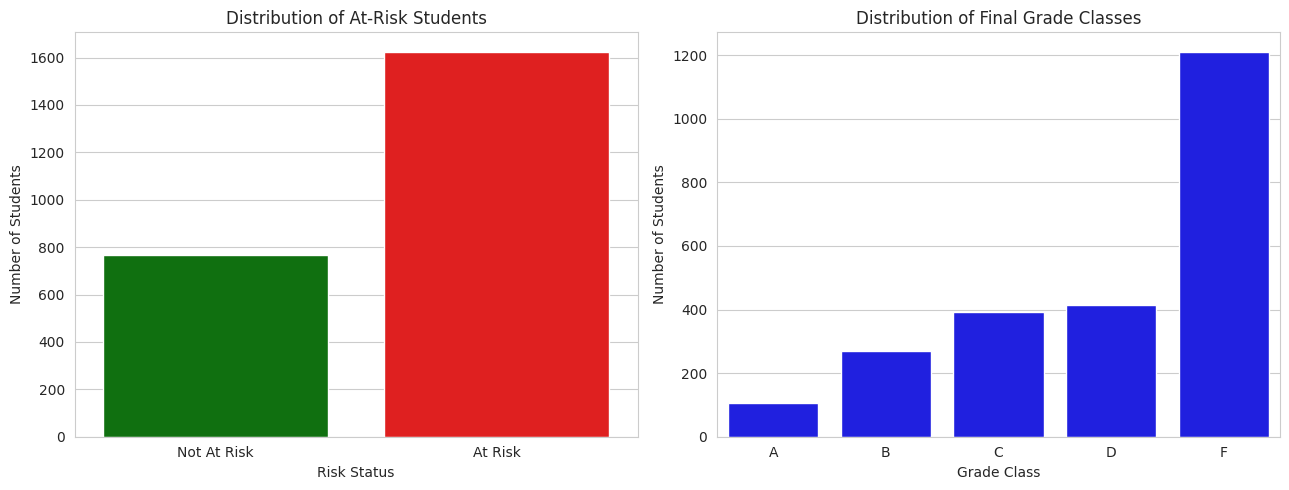

In [7]:
# Visualize the target variable and grade distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# At-Risk distribution
sns.countplot(
    data=df,
    x="AtRisk",
    palette=["green", "red"],
    ax=axes[0]
)

axes[0].set_title("Distribution of At-Risk Students")
axes[0].set_xlabel("Risk Status")
axes[0].set_ylabel("Number of Students")
axes[0].set_xticklabels(["Not At Risk", "At Risk"])

# Original grade distribution
grade_order = ["A", "B", "C", "D", "F"]

sns.countplot(
    data=df,
    x="GradeClassLabel",
    order=grade_order,
    color="blue",
    ax=axes[1]
)

axes[1].set_title("Distribution of Final Grade Classes")
axes[1].set_xlabel("Grade Class")
axes[1].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Step 7.1 Results (Target Variable)

When we graphed the target variable, we confirmed what we saw earlier: the majority of students in this dataset are struggling. We have **1,625 students (about 68%)** in the **At Risk** bucket, and only **767 students (about 32%)** sitting safely in the **Not At Risk** group.

When we looked back at the original letter grades, this imbalance made a lot of sense. Fs and Ds are actually the most common grades given out in this entire dataset, while As and Bs are pretty rare. Since we combined the D and F students into our "At Risk" group, it is naturally going to be much bigger.

Because our two groups are uneven, this is a great reminder that we can't just rely on basic "accuracy" to tell us if our model is doing a good job later on. We will definitely need to pay closer attention to metrics like Recall and F1-Score instead.

Next, we are going to dive into the other columns to see how things like study habits and background relate to these failing grades, so we can figure out the best clues for our model!


## 7.2 Comparing the Numbers

Now we are going to look at our number-based columns to see how the **At Risk** students compare to the **Not At Risk** students.

We put together some basic stats and boxplots to explore things like age, weekly study time, and absences. We are hoping to spot some obvious differences between the two groups—like whether struggling students tend to miss a lot more school. Spotting these trends now will help us pick the best clues for our model to use later.

Just a reminder: we are including GPA in these charts just to see the big picture, but we will drop it before we actually train the model so we don't accidentally cheat!


Age              StudyTimeWeekly              Absences               \
         mean median   std            mean median   std     mean median   std   
AtRisk                                                                          
0       16.49   16.0  1.13           10.71  10.85  5.59     6.36    5.0  5.75   
1       16.46   16.0  1.12            9.33   9.02  5.63    18.40   19.0  6.59   

         GPA               
        mean median   std  
AtRisk                     
0       2.84   2.89  0.61  
1       1.46   1.51  0.67

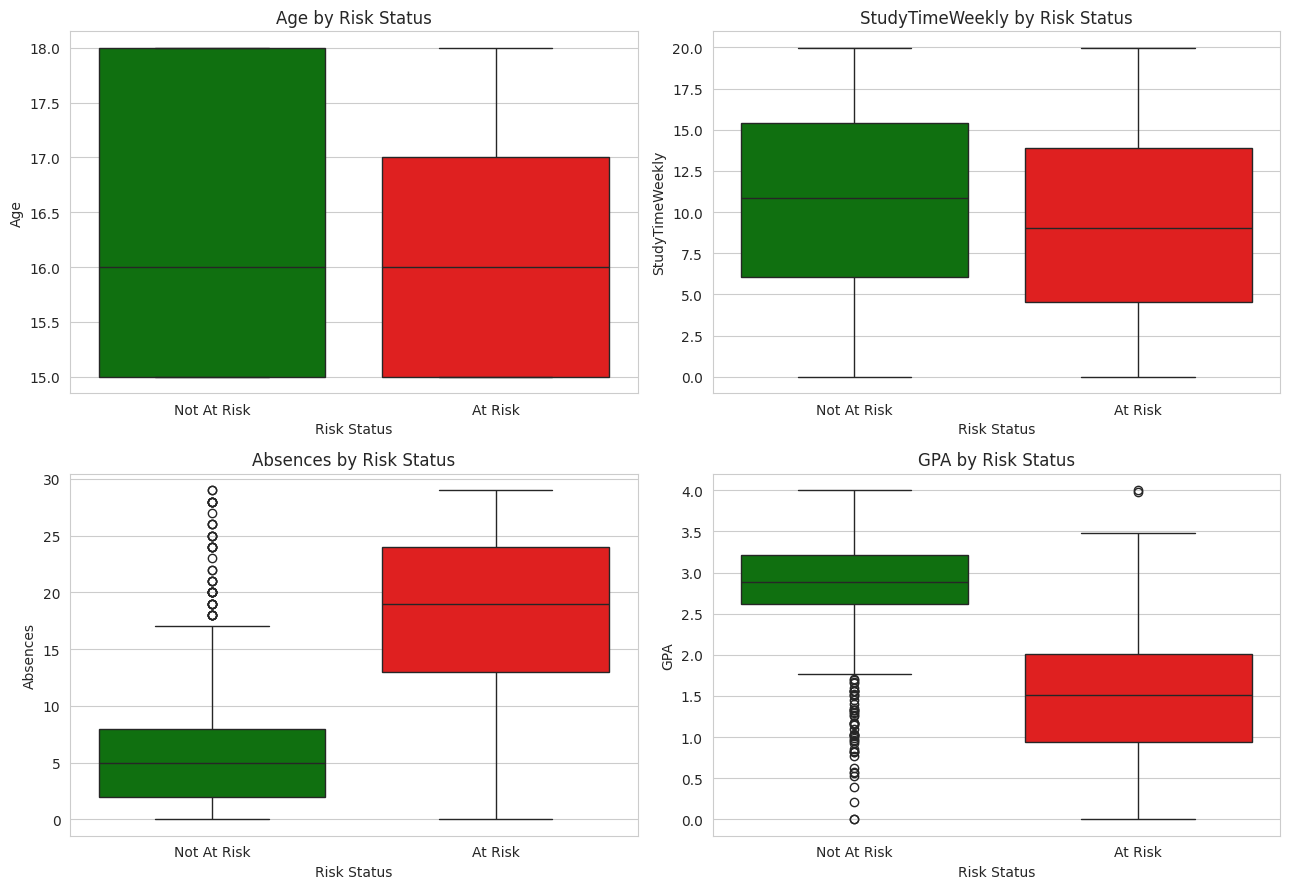

In [8]:
# Compare numerical features by risk group

numeric_features = ["Age", "StudyTimeWeekly", "Absences", "GPA"]

summary_by_risk = (
    df.groupby("AtRisk")[numeric_features]
      .agg(["mean", "median", "std"])
)

display(summary_by_risk.round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for axis, feature in zip(axes, numeric_features):
    sns.boxplot(
        data=df,
        x="AtRisk",
        y=feature,
        hue="AtRisk",
        palette=["green", "red"],
        legend=False,
        ax=axis
    )

    axis.set_title(f"{feature} by Risk Status")
    axis.set_xlabel("Risk Status")
    axis.set_xticklabels(["Not At Risk", "At Risk"])

plt.tight_layout()
plt.show()

### Step 7.2 Results (Comparing the Numbers)

When we compared the numbers for both groups, we found some really obvious differences.

First, age doesn't seem to matter much. Both the struggling and passing students average right around **16.5 years old**, so age probably won't be a huge help in predicting who is at risk.

Weekly study time, on the other hand, definitely makes a difference. The passing students (Not At Risk) study for about **10.7 hours a week**, while the struggling students put in about **9.3 hours**. It makes perfect sense—more studying usually points to better grades.

The biggest takeaway here was the absences. The passing students only missed about **6.4 days** of school, but the At Risk students missed an average of **18.4 days**! If you look at the boxplots, the two groups are almost completely separated. This tells us that bad attendance is going to be a massive red flag for our model.

Naturally, GPA showed a huge gap too (an average of **2.84** for passing students versus **1.46** for struggling ones). This just confirms that our "At Risk" rule worked perfectly. But again, we have to throw GPA out before we train the model so we don't accidentally cheat.

Basically, things like **Absences** and **Study Time** are going to be super helpful for our machine learning model, while **Age** isn't going to tell us much. This proves that habits and attendance play a huge role in spotting the students who need extra help!


## 7.3 Comparing the Categories

Now we are going to look at our category columns. This includes things like a student's background, their parents' education and support levels, and whether they do things outside of regular class time like tutoring, sports, music, or volunteering.

Instead of just counting how many students are in each group, we are going to look at the percentage of students who are "At Risk" within each specific category. This makes it much easier to see if belonging to a certain group (like getting tutoring or having high parental support) actually changes a student's chances of passing.

Basically, we are just looking for more patterns to use as clues for our machine learning model. And just like before, these patterns don't necessarily prove cause-and-effect, we are just seeing what stands out!

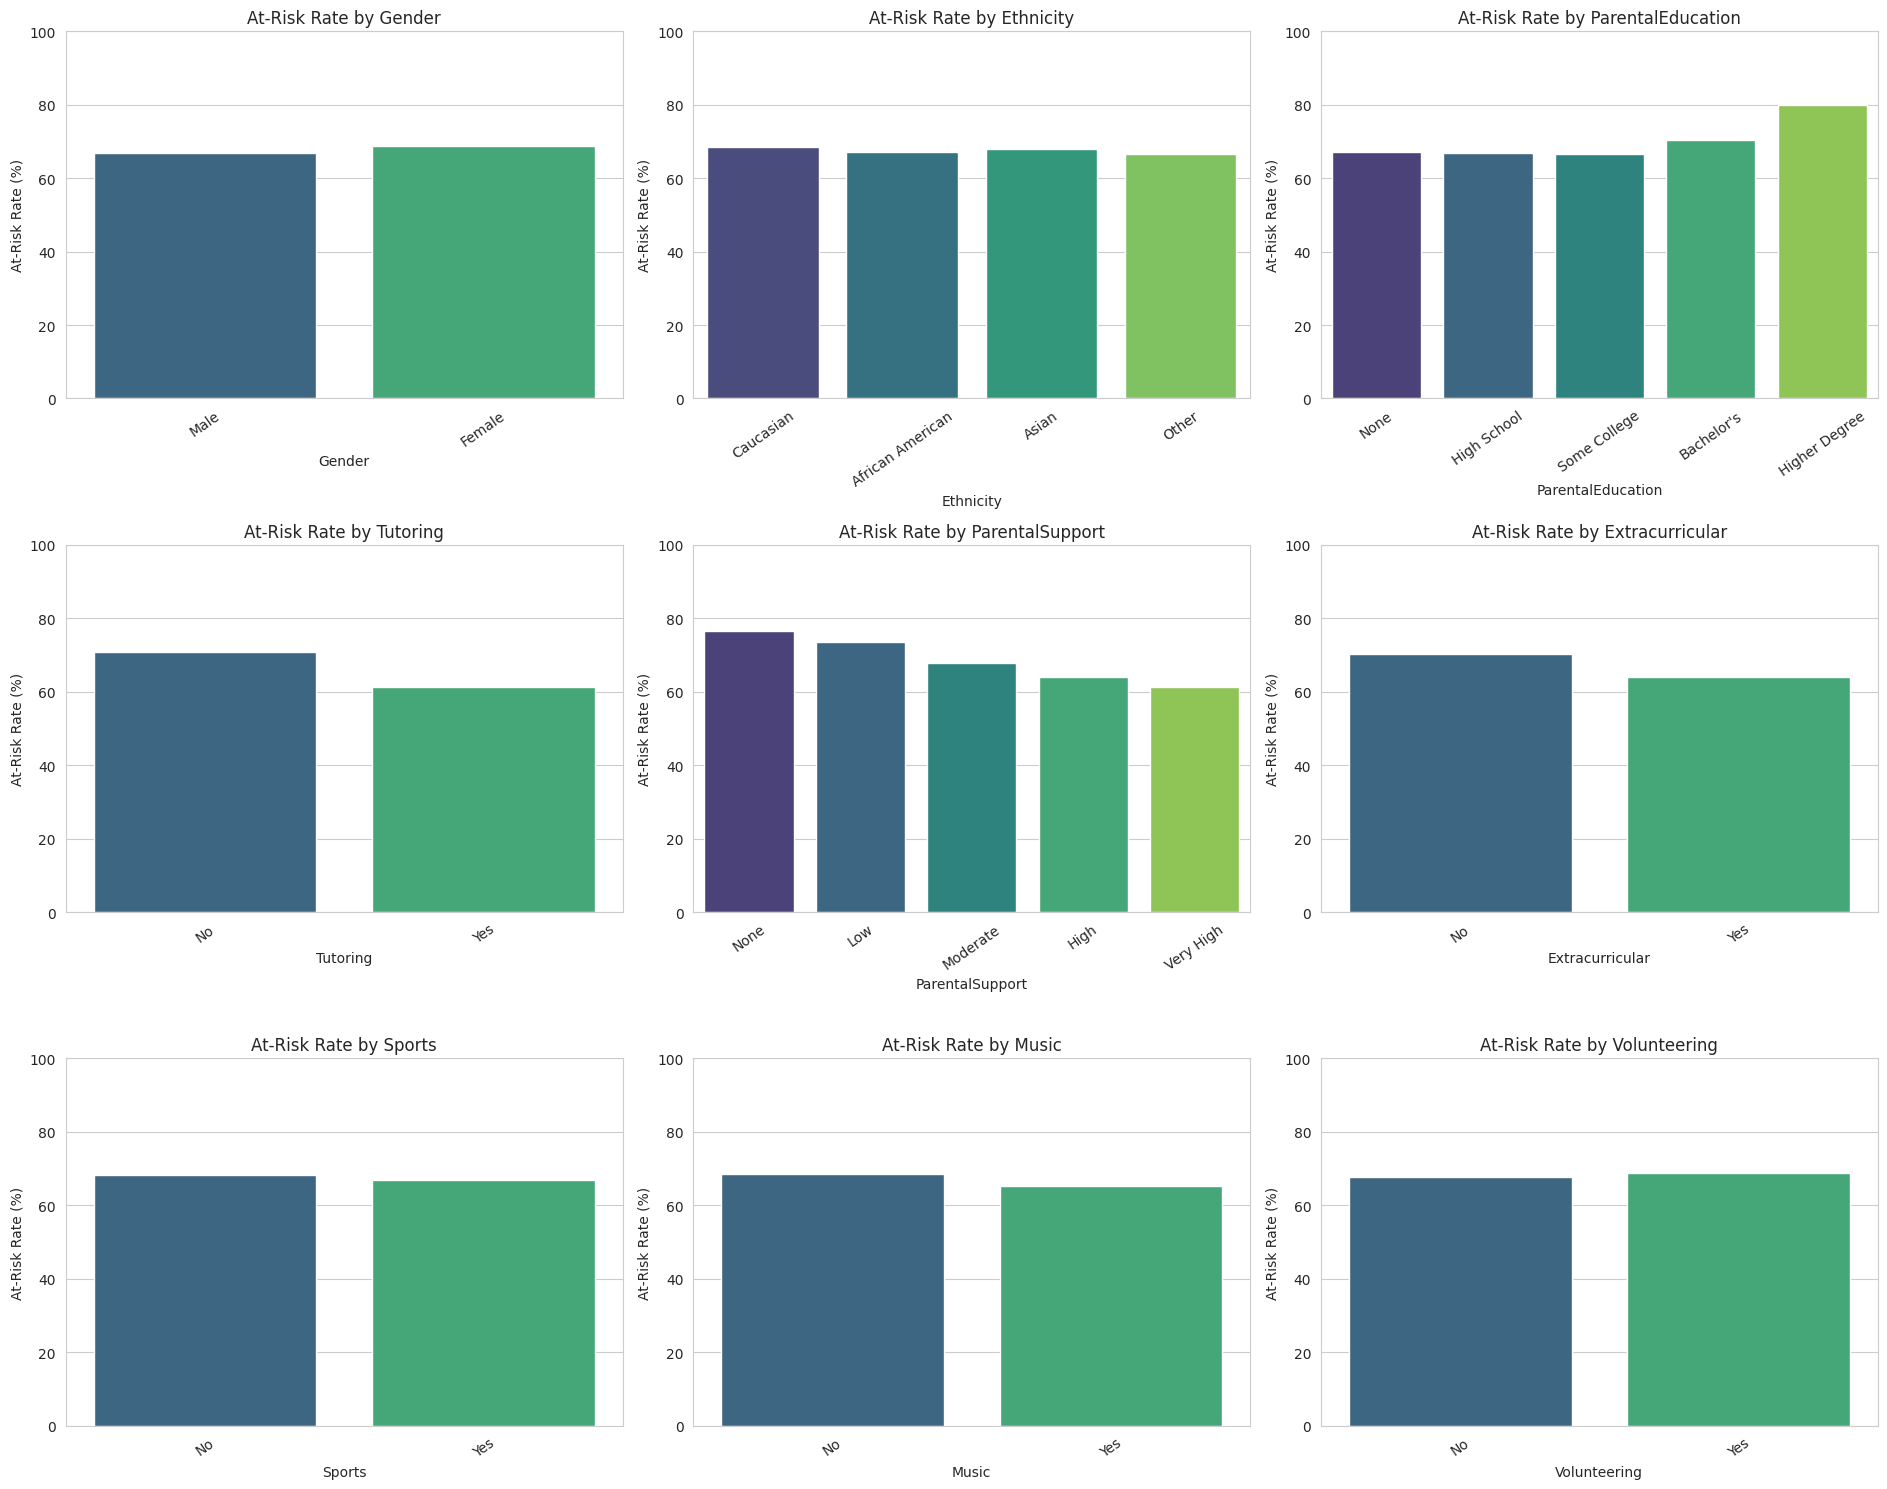


Gender


,Category,At-Risk Rate (%)
0,Male,66.92
1,Female,68.90



Ethnicity


,Category,At-Risk Rate (%)
0,Caucasian,68.43
1,African American,67.14
2,Asian,68.09
3,Other,66.67



ParentalEducation


...

,Category,At-Risk Rate (%)
0,No,68.37
1,Yes,66.94



Music


,Category,At-Risk Rate (%)
0,No,68.61
1,Yes,65.18



Volunteering


,Category,At-Risk Rate (%)
0,No,67.76
1,Yes,68.88


In [9]:
# Compare At-Risk rates across categorical features

label_maps = {
    "Gender": {0: "Male", 1: "Female"},
    "Ethnicity": {0: "Caucasian", 1: "African American", 2: "Asian", 3: "Other"},
    "ParentalEducation": {
        0: "None",
        1: "High School",
        2: "Some College",
        3: "Bachelor's",
        4: "Higher Degree"
    },
    "Tutoring": {0: "No", 1: "Yes"},
    "ParentalSupport": {0: "None", 1: "Low", 2: "Moderate", 3: "High", 4: "Very High"},
    "Extracurricular": {0: "No", 1: "Yes"},
    "Sports": {0: "No", 1: "Yes"},
    "Music": {0: "No", 1: "Yes"},
    "Volunteering": {0: "No", 1: "Yes"}
}

categorical_features = list(label_maps)
risk_rate_tables = {}

fig, axes = plt.subplots(3, 3, figsize=(19, 15))
axes = axes.flatten()

for axis, feature in zip(axes, categorical_features):
    risk_rates = df.groupby(feature)["AtRisk"].mean() * 100
    labels = [label_maps[feature].get(value, str(value)) for value in risk_rates.index]

    risk_rate_tables[feature] = pd.DataFrame({
        "Category": labels,
        "At-Risk Rate (%)": risk_rates.round(2).values
    })

    sns.barplot(
        x=labels,
        y=risk_rates.values,
        hue=labels,
        palette="viridis",
        legend=False,
        ax=axis
    )

    axis.set_title(f"At-Risk Rate by {feature}")
    axis.set_xlabel(feature)
    axis.set_ylabel("At-Risk Rate (%)")
    axis.tick_params(axis="x", rotation=35)
    axis.set_ylim(0, 100)

plt.tight_layout()
plt.show()

for feature, table in risk_rate_tables.items():
    print(f"\n{feature}")
    display(table)

### Step 7.3 Results ((Comparing the Categories)

When we looked at the categories, a few things really stood out.

For example, getting extra help makes a noticeable difference. Only about **61%** of students who get tutoring fall into the At Risk group, compared to about **71%** of students who don't get tutoring.

Parental support also showed a really clear pattern. Students who get a lot of support at home have much lower At-Risk rates, while those with little to no support are far more likely to struggle.

We also saw that students who join extracurricular programs usually have a lower chance of failing. However, just playing sports or being in music didn't show as big of a gap, so those specific activities might not be super strong clues for our model.

We checked gender and ethnicity just to be thorough and make sure our data is fair, but we only saw very minor differences there. (And again, these are just observations, not proof of cause-and-effect!)

Basically, things like tutoring, supportive parents, and being involved in extra activities showed the strongest patterns and will probably be great predictors for our machine learning model!

## 7.4 Finding Relationships (Correlations)

Next, we are going to use a correlation matrix to see how all of our different variables connect to our "At Risk" target.

This step helps us spot which factors have the strongest positive or negative relationships with a student struggling in class. The columns that show the strongest connections here will likely be our best clues when we actually start building our model.

Basically, this is just another way for us to get a feel for the data and find the most important variables. And just like before, seeing a strong connection here doesn't mean one thing automatically causes the other—it just means they tend to move together!

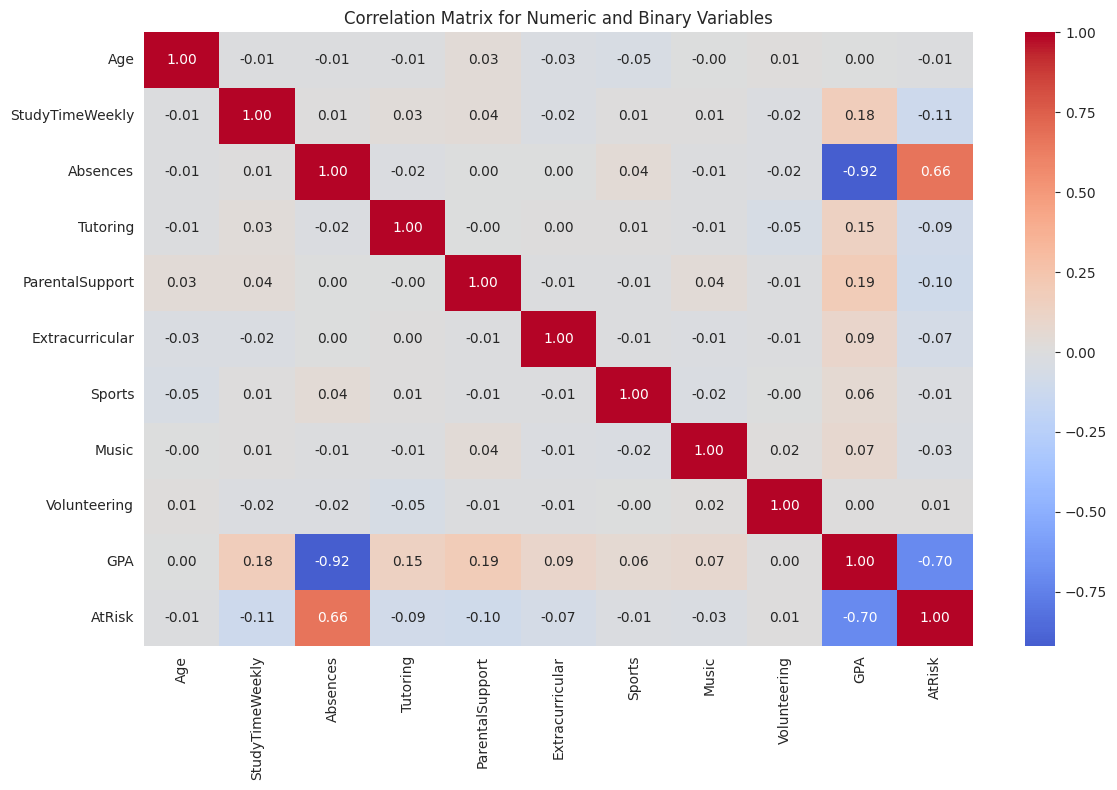

,Correlation with AtRisk
GPA,-0.702296
Absences,0.663861
StudyTimeWeekly,-0.113618
ParentalSupport,-0.098439
Tutoring,-0.093325
Extracurricular,-0.066252
Music,-0.029221
Sports,-0.014040
Age,-0.011599
Volunteering,0.008774


In [10]:
# Correlation analysis

correlation_columns = [
    "Age",
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering",
    "GPA",
    "AtRisk",
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix for Numeric and Binary Variables")
plt.tight_layout()
plt.show()

atrisk_correlations = (
    correlation_matrix["AtRisk"]
    .drop("AtRisk")
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame("Correlation with AtRisk")
)

display(atrisk_correlations)

### Step 7.4 Results (Correlation)

When we looked at the correlation numbers, **Absences** and **GPA** stood out the most.

Absences showed a strong positive connection (**0.66**). Simply put, the more days a student misses, the more likely they are to fall into the At Risk group.

GPA showed a strong negative connection (**-0.70**), meaning lower grades equal a higher chance of being at risk. But to sound like a broken record, we are still throwing GPA out before we build our model so we don't accidentally cheat!

We also saw some smaller, but still helpful, connections with things like study time, parental support, getting tutoring, and joining extra activities. Just like we noticed in our earlier charts, having these good habits and support systems lowers a student's risk of failing.

On the flip side, things like age, playing sports, or doing music barely showed any connection to academic risk at all.

Basically, simply showing up to class is the most important factor we've found. But good study habits, supportive parents, and extra help are also going to be really useful clues when we start building our machine learning models!

# 8. Final Check and Choosing Our Features

Before we actually start building our model, we have to drop a few columns that either won't help us at all or would give the model an unfair advantage. Here is exactly what we are removing:

* **Student ID:** This is just a random number used to keep track of the rows. It has nothing to do with a student's performance, so it won't help the model predict anything.
* **GradeClass & GradeClassLabel:** We used these exact letter grades to create our "At Risk" target rule in the first place, so we obviously can't use them to make predictions!
* **GPA:** We have mentioned this a few times already, but GPA is just too close to the final outcome. Giving the model the student's GPA is basically like handing it the answer key to the test.

Basically, we are throwing these columns out to make sure our model is only learning from clues that a teacher or counselor would actually have *before* a student's final grades come out.

In [11]:
# Remove identifier and leakage features

leakage_columns = [
    "StudentID",
    "GPA",
    "GradeClass",
    "GradeClassLabel",
]

X = df.drop(columns=leakage_columns + ["AtRisk"])
y = df["AtRisk"].copy()

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

print("\nPredictor Columns:")
print(X.columns.tolist())

assert not set(leakage_columns).intersection(X.columns)
assert y.name == "AtRisk"

Feature Matrix Shape: (2392, 12)
Target Shape: (2392,)

Predictor Columns:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']


### Step 8 Results (finalizing Our Features)

We successfully cleaned up our dataset. As planned, we dropped those four columns: **StudentID**, **GradeClass**, **GradeClassLabel**, and **GPA**.

Just to mention, we got rid of these because they either don't mean anything (like an ID number) or they give away the final answer. If we kept them, our model would look incredibly accurate, but it would be completely useless in the real world since it would be cheating.

After clearing those out, we are left with exactly **2,392 student records** and **12 useful columns** (our features) to help us predict our **At Risk** target.

The 12 columns we kept cover things like background, study habits, absences, and parental support. This is absolutely perfect for an early-warning system because teachers actually have access to this kind of information *before* final grades are handed out.

Basically, our feature set is completely locked in and we are ready to start building our machine learning models!


# 9. Getting the Data Ready for the Model (Preprocessing)

To make sure we treat our data the exact same way every single time, we are wrapping all of our prep work into what is called a Scikit-learn "pipeline." We can think of this like an automated assembly line for our data. This ensures everything is perfectly consistent when we train the model, test it, and even if we deploy it in the real world later.

Here is exactly what our assembly line does:
* **Ethnicity:** We are splitting this into separate Yes/No columns (which is called one-hot encoding).
* **Gender & Activities:** These are already set up perfectly as 0s and 1s, so we are leaving them alone.
* **Parental Education & Support:** We are keeping these exactly as they are since they have a natural, ranked order.
* **Numbers:** We are scaling our number columns (like study hours and absences) so everything is on an even playing field.
* **Unknowns:** If the model ever comes across a brand new category later on, the pipeline is set up to handle it automatically without crashing.

Basically, even though the specific models we are going to use (like Random Forest and XGBoost) don't technically *need* the number columns to be scaled, building one master pipeline just keeps our whole project clean, simple, and consistent!


In [12]:
# Create the preprocessing pipeline

nominal_features = ["Ethnicity"]

scaled_numeric_features = [
    "Age",
    "StudyTimeWeekly",
    "Absences"
]

pass_through_features = [
    "Gender",
    "ParentalEducation",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "nominal",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            ),
            nominal_features,
        ),
        (
            "scaled_numeric",
            StandardScaler(),
            scaled_numeric_features,
        ),
        (
            "passthrough",
            "passthrough",
            pass_through_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


### Step 9 Results (Setting Up the Pipeline)

We built our automated assembly line to prep our data. This makes sure every single piece of information gets treated the exact same way throughout the whole project.

Here is how we handled the different columns:
* **Ethnicity:** We split this into separate Yes/No columns. Plus, we set it up so that if the model ever sees a brand new category later, it will handle it automatically instead of crashing.
* **The Numbers:** We scaled our number columns (like Age, weekly study time, and absences) so they are all measured on the same level. Our specific machine learning models don't strictly need this, but doing it anyway keeps our entire workflow super consistent.
* **Everything Else:** All the other columns—like Gender, Parental Education, Tutoring, and extra activities were left exactly as they are because they are already formatted perfectly for the model to read.

Basically, our data prep pipeline is completely locked in and ready to start training our models!


# 10. Data Preparation for Modeling

Now that our data is clean and our assembly line is set up, it is time to split our dataset up so we can actually start training our machine learning models.

First, we took all of our student records and split them into two separate groups:
* **The Training Set (80%):** This is the data we will use to "teach" our model what an At Risk student looks like.
* **The Testing Set (20%):** This is the final exam for our model. We are locking this data away, and the model won't get to see it at all until the very end of the project.

When we split the data, we were really careful to make sure the ratio of struggling students to passing students stayed exactly the same in both groups, just to keep things completely fair.

Finally, we ran our training data through that automated assembly line we built in Step 9 to set all the formatting rules, and then we applied those exact same rules to our test data. We have to do it in this specific order so our model doesn't accidentally peek at the test data and cheat!

Basically, everything is perfectly prepped, the test data is safely hidden away, and it is finally time to start training our models!

In [13]:
# Step 10.1 (splitting the data)
# Create training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "Rows": [len(X_train), len(X_test)],
        "At-Risk Rate (%)": [
            y_train.mean() * 100,
            y_test.mean() * 100,
        ],
    },
    index=["Training", "Testing"],
)

display(split_summary.round(2))

assert set(X_train.index).isdisjoint(set(X_test.index))
assert X_train.columns.equals(X_test.columns)

print("Train-test split checks passed.")

,Rows,At-Risk Rate (%)
Training,1913,67.96
Testing,479,67.85


Train-test split checks passed.


### Step 10.1 Results (Splitting the Data)

We split our dataset into our two groups: 80% for training and 20% for testing.

Our training group ended up with **1,913 students**, and our hidden testing group has **479 students**. We were incredibly careful to make sure the ratio of struggling students stayed consistent across both groups. We double-checked the numbers, and the At-Risk rate is almost exactly the same in both sets (about **68%**). This means our split worked perfectly and kept things completely fair!

We also did a quick sweep to make sure no student accidentally ended up in both groups and that all of our columns match up perfectly.

Basically, our data is officially split up and we are completely ready to start training the models!

In [14]:
# Apply preprocessing

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

prepared_feature_names = preprocessor.get_feature_names_out()

X_train_prepared_df = pd.DataFrame(
    X_train_prepared,
    columns=prepared_feature_names,
    index=X_train.index
)

X_test_prepared_df = pd.DataFrame(
    X_test_prepared,
    columns=prepared_feature_names,
    index=X_test.index
)

print("Prepared Training Shape:", X_train_prepared_df.shape)
print("Prepared Testing Shape:", X_test_prepared_df.shape)

display(X_train_prepared_df.head())

assert not X_train_prepared_df.isna().any().any()
assert not X_test_prepared_df.isna().any().any()

print("Prepared data contains no missing values.")

Prepared Training Shape: (1913, 14)
Prepared Testing Shape: (479, 14)


,Ethnicity_1,Ethnicity_2,Ethnicity_3,Age,StudyTimeWeekly,Absences,Gender,ParentalEducation,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering
1344,1.0,0.0,0.0,0.475659,-0.118579,0.655446,0.0,1.0,1.0,3.0,0.0,0.0,0.0,0.0
604,0.0,0.0,0.0,0.475659,-0.107315,1.246837,0.0,2.0,1.0,3.0,0.0,0.0,0.0,1.0
1848,1.0,0.0,0.0,-1.303296,0.112901,0.064055,1.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0
1883,1.0,0.0,0.0,-1.303296,-1.008665,1.246837,0.0,2.0,0.0,2.0,1.0,1.0,1.0,0.0
612,1.0,0.0,0.0,1.365136,-1.635186,-0.172502,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


Prepared data contains no missing values.


### Step 10.2 Results (Running the Data Through the Pipeline)

We took our training data and ran it through that assembly line we just built. We made sure the pipeline only learned the formatting rules from the *training* group, and then we carefully applied those exact same rules to our hidden testing group. Doing it this way guarantees our model doesn't accidentally peek at the test data and cheat!

After running everything through, we still have our **1,913 training students** and **479 testing students**, but our 12 columns expanded into **14 columns**. We didn't add any new data, this just happened because we split the Ethnicity category into separate Yes/No columns.

We did a quick double-check on the final output to make sure our numbers scaled correctly, our categories were perfectly formatted, and the pipeline didn't accidentally create any blank spaces.

Basically, our datasets are locked in, fully prepped, and we are finally ready to start building the actual machine learning models!


# 11. Getting Ready to Build the Models

Our data has officially passed all the checks. We explored the patterns, picked our clues, set up our assembly line, and split our data. Now, we are finally ready to start building and testing our machine learning models!

## The Models We Are Building

We are going to test out three different models to see which one performs the best:
1. **Decision Tree:** A simple, straightforward baseline model that is really easy for humans to understand.
2. **Random Forest:** A more advanced model that uses a whole group of decision trees working together.
3. **XGBoost:** A heavy-duty, highly complex model that learns from its own mistakes over time.

## How We Will Grade the Models

To figure out which model is the winner, we are going to run some practice tests on our training data (this is called cross-validation).

During these tests, we will:
* Keep our automated data prep pipeline firmly in place.
* Make sure the ratio of struggling to passing students stays consistent.
* Keep our final 20% test data completely locked away until the very end.

Because our main goal is to catch students *before* they fail, we can't just look at basic "accuracy." Instead, we will be grading the models using specific metrics like **Recall**, **Precision**, **F1-Score**, and **ROC-AUC** to make sure they are actually good at spotting the At-Risk kids.

## Handling Our Uneven Groups

Since we have more struggling students in our dataset than passing students, we have to keep an eye on how the model learns.

We will start by training the models on the data exactly as it is. But, if the models struggle to identify the At-Risk students, we might try some extra techniques like giving the At-Risk students more "weight" or creating synthetic examples to balance the scales. (If we do this, we will only do it on the training data so we don't accidentally cheat!)

## Keeping Things Fair (Responsible AI)

Before we even think about using this tool in the real world, we have to make sure it is completely fair.

We will check to see how the model performs across different genders and ethnicities. We want to make sure it isn't accidentally missing students or falsely flagging them based on their background. The whole point of this project is to point teachers toward students who need extra support, never to make automated decisions that could hold a student back.

## Final Thoughts Before We Build

Basically, we threw out the cheating variables, verified our target goal, safely locked away our test data, and mapped out exactly how we are going to grade our work. We are officially ready to start building our models!

# 12. Building the Machine Learning Models

Now we are finally going to build our machine learning models to predict which students are at risk of failing and need extra support.

Just to recap, we are completely leaving out GPA and the original letter grades so the model can't cheat. Instead, the models will only learn from clues like attendance, study habits, parental support, tutoring, and extracurricular activities.

## The Models We Are Testing

We decided to train and compare three different models, ranging from simple to complex:

1. **Decision Tree:** A very simple, easy-to-understand baseline model.
2. **Random Forest:** A more advanced model that uses a whole group of decision trees working together.
3. **XGBoost:** Our most complex, heavy-duty model.

## How We Are Grading Them

To see which model is the actual best, we are going to run practice tests (cross-validation) on our training data, and then give them a final exam on our hidden testing data.

We are going to grade the models using a few different scores:
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

Because the whole point of this project is to catch struggling students before they slip through the cracks, we care the absolute most about **Recall** and avoiding **False Negatives**.

Basically, missing an at-risk student is a much bigger deal than accidentally flagging a passing student for a quick review. We are going to pick our winning model based on which one is the best at making sure no student gets left behind!

## 12.1 Our First Model: The Decision Tree

We are starting with a Decision Tree. We can think of this model like a giant flowchart. It asks a series of simple Yes/No questions about a student—like "Do they have more than 10 absences?" or "Do they study more than 5 hours a week?"—to make its final prediction.

We love starting with this model because it is incredibly easy for humans to read. We can literally look at the "tree" and understand exactly why it decided a student was at risk.

Just like we planned out earlier, we are going to run this model through some practice tests (cross-validation) using our training data. Once it finishes practicing, we will give it its final exam on our hidden testing data.

We will grade the model using our standard scorecard:
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

But remember, our main goal is to make sure no struggling student slips through the cracks. Because of that, we are going to pay the most attention to **Recall** (which measures how many of the actual at-risk students our model successfully caught).

Basically, this simple model is going to serve as our starting baseline. We will use its scores to see if our more complex models are actually an improvement.

Decision Tree Cross-Validation Performance
--------------------------------------------------
CV Accuracy: 0.8657
CV Precision: 0.8767
CV Recall: 0.9338
CV F1-Score: 0.9043
CV ROC-AUC: 0.8920

Decision Tree Test Performance
--------------------------------------------------
Accuracy : 0.8518
Precision: 0.8735
Recall   : 0.9138
F1-Score : 0.8932
ROC-AUC  : 0.8826

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.72      0.76       154
           1       0.87      0.91      0.89       325

    accuracy                           0.85       479
   macro avg       0.84      0.82      0.83       479
weighted avg       0.85      0.85      0.85       479



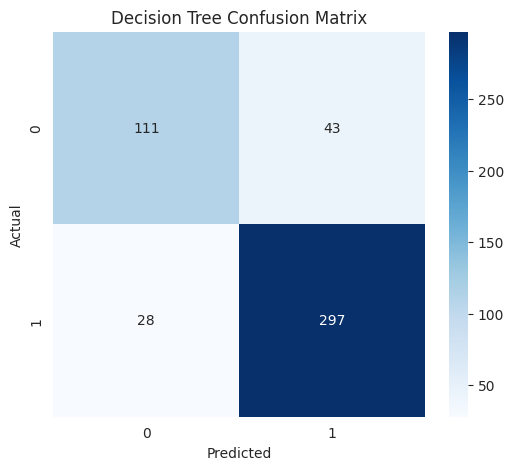

In [ ]:
# Decision Tree model

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        )
    )
])

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Cross-validation
dt_cv_results = cross_validate(
    dt_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics,
    return_train_score=False
)

dt_cv_summary = {
    "CV Accuracy": dt_cv_results["test_accuracy"].mean(),
    "CV Precision": dt_cv_results["test_precision"].mean(),
    "CV Recall": dt_cv_results["test_recall"].mean(),
    "CV F1-Score": dt_cv_results["test_f1"].mean(),
    "CV ROC-AUC": dt_cv_results["test_roc_auc"].mean()
}

print("Decision Tree Cross-Validation Performance")
print("-" * 50)

for metric, value in dt_cv_summary.items():
    print(f"{metric}: {value:.4f}")

# Train and evaluate
dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("\nDecision Tree Test Performance")
print("-" * 50)
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 12.1 Results (Decision Tree Model)

Our very first model actually did a pretty great job. Before giving it the final exam, we ran a **5-fold stratified cross-validation** on our training data to make sure it was learning properly. It was super consistent, averaging around **86.6% accuracy** and a **93.4% Recall**.

When we finally let it take the test on our hidden 20% dataset, the scores held up really well:
* **Accuracy:** 85.2%
* **Precision:** 87.4%
* **Recall:** 91.4%
* **F1-Score:** 89.3%
* **ROC-AUC:** 88.3%

Since our main goal is to catch students before they fail, we care the most about that **91.4% Recall score**. To put that into real human terms, here is exactly how the model performed on the test group:
* **Caught 297 struggling students** (True Positives)
* **Recognized 111 safe students** (True Negatives)
* **Accidentally flagged 43 safe students** (False Positives—not a big deal, a counselor just checks on them and realizes they are fine).
* **Missed 28 struggling students** (False Negatives—the ones we need to worry about).

While catching over 91% of the at-risk students is a really strong start, missing 28 kids means there is definitely still room for improvement.

Basically, this Decision Tree gave us a fantastic baseline to work from, but now it is time to see if our more advanced models can track down those missing 28 students!

## 12.2 Random Forest Model

In this step we try the Random Forest. It does exactly what the name suggests, instead of relying on just one single Decision Tree, it builds an entire "forest" of them!

Here is how it works: the model builds hundreds of different trees using slightly different pieces of our data. When it is time to make a prediction, it asks every single tree for its opinion and then takes a vote. Because it relies on teamwork instead of just one perspective, this model is usually much more reliable than our first one.

Just like before, we are going to put this model through a **5-fold stratified cross-validation** on our training data before letting it take the final exam on our hidden testing data.

We will grade it using the exact same scorecard:
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

As always, since our main goal is to make sure struggling students get help, we are paying the closest attention to **Recall** and trying to avoid False Negatives.

Basically, we are hoping this "forest" approach will improve on our baseline scores and track down even more of those at-risk students!


Random Forest Cross-Validation Performance
--------------------------------------------------
CV Accuracy: 0.8887
CV Precision: 0.9012
CV Recall: 0.9392
CV F1-Score: 0.9198
CV ROC-AUC: 0.9225

Random Forest Test Performance
--------------------------------------------------
Accuracy : 0.8768
Precision: 0.8844
Recall   : 0.9415
F1-Score : 0.9121
ROC-AUC  : 0.9235

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       154
           1       0.88      0.94      0.91       325

    accuracy                           0.88       479
   macro avg       0.87      0.84      0.85       479
weighted avg       0.88      0.88      0.87       479



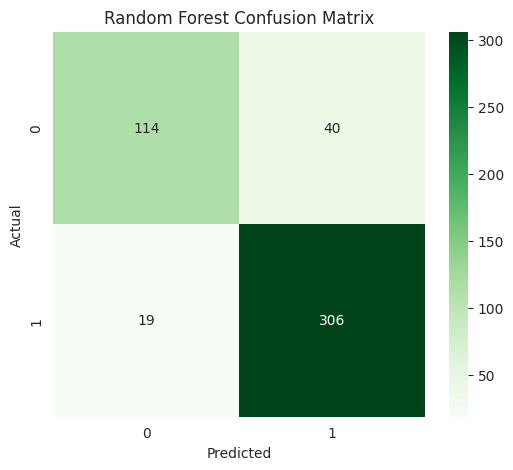

In [16]:
# Random Forest model

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42
        )
    )
])

# Cross-validation
rf_cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics,
    return_train_score=False
)

rf_cv_summary = {
    "CV Accuracy": rf_cv_results["test_accuracy"].mean(),
    "CV Precision": rf_cv_results["test_precision"].mean(),
    "CV Recall": rf_cv_results["test_recall"].mean(),
    "CV F1-Score": rf_cv_results["test_f1"].mean(),
    "CV ROC-AUC": rf_cv_results["test_roc_auc"].mean()
}

print("Random Forest Cross-Validation Performance")
print("-" * 50)

for metric, value in rf_cv_summary.items():
    print(f"{metric}: {value:.4f}")

# Train and evaluate
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("\nRandom Forest Test Performance")
print("-" * 50)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 12.2 Results (Random Forest Model)

First, we ran it through the **5-fold stratified cross-validation** on our training data. It was incredibly consistent, averaging around **88.9% accuracy** and an impressive **93.9% Recall**. This tells us that the teamwork approach is very stable and doesn't get confused easily by different chunks of data.

When we finally handed it the final exam (our hidden 20% test data), it performed very good. Here is the final scorecard:
* **Accuracy:** 87.7%
* **Precision:** 88.4%
* **Recall:** 94.1%
* **F1-Score:** 91.2%
* **ROC-AUC:** 92.3%

Remember, we care the most about that Recall score because we want to catch as many struggling students as possible. A **94.1% Recall** is fantastic. Here is exactly what that looked like in real numbers for our test group:
* **Caught 306 struggling students** (True Positives—we found more of them!)
* **Recognized 114 safe students** (True Negatives)
* **Accidentally flagged 40 safe students** (False Positives—still not a big deal).
* **Missed 19 struggling students** (False Negatives).

So, how did it compare to our simple Decision Tree? It worked better. Accuracy, F1-Score, and ROC-AUC all jumped up. But most importantly, the number of struggling students that slipped through the cracks dropped from **28 down to just 19**.

Basically, the Random Forest is our new choice model in comparison with Decision Tree. Now, let's see how our final model, XGBoost perfrom in comparsion with these two models.


## 12.3 XGBoost Model

Our final model is XGBoost. While Random Forest builds many independent decision trees all at once, XGBoost takes a sequential approach: it builds trees one by one.

The key advantage of XGBoost is that every time it builds a new tree, that tree is specifically designed to correct the errors made by the previous trees. Because it actively learns from its mistakes as it progresses, XGBoost is highly effective at identifying complex patterns in the data.

To keep our evaluation process consistent, we first evaluated the model using a **5-fold stratified cross-validation** on the training data. This allowed us to test the model's stability across different sections of the data while ensuring the ratio of at-risk to passing students remained balanced.

After completing the cross-validation, the model was trained on the full training dataset and evaluated on our reserved testing dataset.

We measured its performance using our standard evaluation metrics:
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

As with the previous models, because the primary goal of this project is to identify students who need early intervention, we paid the closest attention to **Recall** and minimizing False Negatives.

The final results from XGBoost will be compared directly against the Decision Tree and Random Forest models to determine which approach is the most effective for identifying at-risk students.



XGBoost Cross-Validation Performance
--------------------------------------------------
CV Accuracy: 0.8907
CV Precision: 0.9016
CV Recall: 0.9423
CV F1-Score: 0.9214
CV ROC-AUC: 0.9239

XGBoost Test Performance
--------------------------------------------------
Accuracy : 0.8894
Precision: 0.8953
Recall   : 0.9477
F1-Score : 0.9208
ROC-AUC  : 0.9294

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.77      0.82       154
           1       0.90      0.95      0.92       325

    accuracy                           0.89       479
   macro avg       0.88      0.86      0.87       479
weighted avg       0.89      0.89      0.89       479



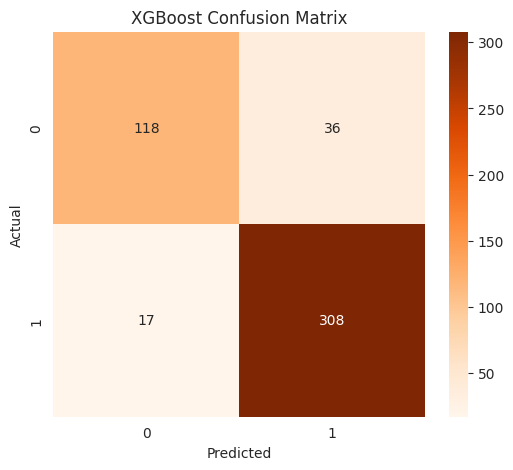

In [17]:
# XGBoost model

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        )
    )
])

# Cross-validation
xgb_cv_results = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics,
    return_train_score=False
)

xgb_cv_summary = {
    "CV Accuracy": xgb_cv_results["test_accuracy"].mean(),
    "CV Precision": xgb_cv_results["test_precision"].mean(),
    "CV Recall": xgb_cv_results["test_recall"].mean(),
    "CV F1-Score": xgb_cv_results["test_f1"].mean(),
    "CV ROC-AUC": xgb_cv_results["test_roc_auc"].mean()
}

print("XGBoost Cross-Validation Performance")
print("-" * 50)

for metric, value in xgb_cv_summary.items():
    print(f"{metric}: {value:.4f}")

# Train and evaluate
xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("\nXGBoost Test Performance")
print("-" * 50)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 12.3 Results (XGBoost Model)

The XGBoost model was first evaluated using **5-fold stratified cross-validation** on the training dataset. The average cross-validation accuracy was **89.07%**, with a precision of **90.16%**, recall of **94.23%**, F1-score of **92.14%**, and ROC-AUC of **92.39%**.

These results are very similar across the validation folds, suggesting that the model performs consistently on different subsets of the training data.

After cross-validation, the model was trained on the full training dataset and evaluated on the testing dataset. XGBoost achieved an accuracy of **88.94%**, a precision score of **89.53%**, a recall score of **94.77%**, an F1-score of **92.08%**, and a ROC-AUC score of **92.94%**.

Recall is one of the most important metrics in this project because the goal is to identify students who may need academic support. The model correctly identified nearly **95%** of at-risk students in the testing dataset.

The confusion matrix shows that:

* **308** at-risk students were correctly identified (True Positives).
* **118** not-at-risk students were correctly identified (True Negatives).
* **36** not-at-risk students were incorrectly classified as at risk (False Positives).
* **17** at-risk students were incorrectly classified as not at risk (False Negatives).

Among the three models, XGBoost produced the fewest false negatives. Since missing an at-risk student is more concerning than incorrectly flagging a student for review, this is an important result.

Compared with the Decision Tree and Random Forest models, XGBoost achieved the strongest overall performance. Accuracy increased to **88.94%**, recall improved to **94.77%**, F1-score reached **92.08%**, and ROC-AUC increased to **92.94%**. The number of false negatives also decreased from **28** in the Decision Tree model and **19** in the Random Forest model to **17**.

The cross-validation results are also very close to the final testing results, suggesting that the model performs consistently on both training and unseen data.

Overall, XGBoost achieved the best results among the models evaluated in this project and was selected as the final model for the student early-warning system.


## 12.4 Model Comparison

In this section, the performance of the three supervised learning models is compared using both **5-fold stratified cross-validation results** and **final testing results**.

Although accuracy is reported, this project places greater emphasis on recall because the goal is to identify students who may need academic support. Missing an at-risk student is generally more concerning than incorrectly flagging a student for additional review.

The models are compared using:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

The cross-validation results help show how consistently each model performs across different training folds, while the testing results show how well the models perform on unseen data.

The model with the strongest overall results, especially in recall, F1-score, and ROC-AUC, will be selected as the final model for this project.


In [18]:
# Compare model performance

comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "CV Accuracy": [
        dt_cv_summary["CV Accuracy"],
        rf_cv_summary["CV Accuracy"],
        xgb_cv_summary["CV Accuracy"]
    ],
    "CV Recall": [
        dt_cv_summary["CV Recall"],
        rf_cv_summary["CV Recall"],
        xgb_cv_summary["CV Recall"]
    ],
    "CV F1-Score": [
        dt_cv_summary["CV F1-Score"],
        rf_cv_summary["CV F1-Score"],
        xgb_cv_summary["CV F1-Score"]
    ],
    "CV ROC-AUC": [
        dt_cv_summary["CV ROC-AUC"],
        rf_cv_summary["CV ROC-AUC"],
        xgb_cv_summary["CV ROC-AUC"]
    ],
    "Test Accuracy": [
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Test Precision": [
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Test Recall": [
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "Test F1-Score": [
        dt_f1,
        rf_f1,
        xgb_f1
    ],
    "Test ROC-AUC": [
        dt_auc,
        rf_auc,
        xgb_auc
    ]
})

comparison_df = comparison_df.round(4)

display(comparison_df)

print("\nBest Model by Metric")
print("-" * 40)

metrics = [
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1-Score",
    "Test ROC-AUC"
]

for metric in metrics:
    best_model = comparison_df.loc[
        comparison_df[metric].idxmax(),
        "Model"
    ]

    best_score = comparison_df[metric].max()

    print(f"{metric}: {best_model} ({best_score:.4f})")

,Model,CV Accuracy,CV Recall,CV F1-Score,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test ROC-AUC
0,Decision Tree,0.8657,0.9338,0.9043,0.8920,0.8518,0.8735,0.9138,0.8932,0.8826
1,Random Forest,0.8887,0.9392,0.9198,0.9225,0.8768,0.8844,0.9415,0.9121,0.9235
2,XGBoost,0.8907,0.9423,0.9214,0.9239,0.8894,0.8953,0.9477,0.9208,0.9294



Best Model by Metric
----------------------------------------
Test Accuracy: XGBoost (0.8894)
Test Precision: XGBoost (0.8953)
Test Recall: XGBoost (0.9477)
Test F1-Score: XGBoost (0.9208)
Test ROC-AUC: XGBoost (0.9294)


## 12.4 Results (Model Comparison)

The model comparison shows that **XGBoost performed better than the other models** across both cross-validation and testing results.

During **5-fold stratified cross-validation**, XGBoost achieved the highest average accuracy (**89.07%**), recall (**94.23%**), F1-score (**92.14%**), and ROC-AUC (**92.39%**). Random Forest produced the second-best results, while the Decision Tree had the lowest performance across most metrics.

The testing results showed a similar pattern. XGBoost achieved the highest accuracy (**88.94%**), precision (**89.53%**), recall (**94.77%**), F1-score (**92.08%**), and ROC-AUC (**92.94%**). Random Forest again ranked second, followed by the Decision Tree.

Recall is especially important in this project because the goal is to identify students who may need academic support. XGBoost correctly identified **94.77%** of at-risk students and produced only **17 false negatives**, the lowest number among the three models.

The results also show that the ensemble models performed better than the single Decision Tree. Random Forest improved performance by combining multiple trees, while XGBoost achieved further improvements through boosting.

The cross-validation results were also very similar to the final testing results, suggesting that the models performed consistently on both training and unseen data.

Overall, XGBoost achieved the best results in this project and was selected as the final model for the student early-warning system.


## 12.5 Final Model Selection

After comparing the Decision Tree, Random Forest, and XGBoost models, the best-performing model is selected.

The selection is based primarily on **Recall**, **F1-Score**, and **ROC-AUC**, since these metrics are most important for identifying students who may need academic support.

Both cross-validation and testing results are considered when making the final decision. Cross-validation helps evaluate how consistently a model performs across different training folds, while the testing results show how well the model performs on unseen data.

The next section presents the final model selected for this project.


In [19]:
# Final model selection

best_model = "XGBoost"

print(f"Selected Model: {best_model}")

print("\nCross-Validation Results")
print(f"Accuracy : {xgb_cv_summary['CV Accuracy']:.4f}")
print(f"Recall   : {xgb_cv_summary['CV Recall']:.4f}")
print(f"F1-Score : {xgb_cv_summary['CV F1-Score']:.4f}")
print(f"ROC-AUC  : {xgb_cv_summary['CV ROC-AUC']:.4f}")

print("\nTest Results")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

print("\nWhy XGBoost was selected:")
print("- Best overall performance")
print("- Highest recall")
print("- Highest F1-score")
print("- Highest ROC-AUC")
print("- Fewest false negatives")

Selected Model: XGBoost

Cross-Validation Results
Accuracy : 0.8907
Recall   : 0.9423
F1-Score : 0.9214
ROC-AUC  : 0.9239

Test Results
Accuracy : 0.8894
Precision: 0.8953
Recall   : 0.9477
F1-Score : 0.9208
ROC-AUC  : 0.9294

Why XGBoost was selected:
- Best overall performance
- Highest recall
- Highest F1-score
- Highest ROC-AUC
- Fewest false negatives


## 12.5 Results (Final Model Selection)

The model evaluation process identified **XGBoost** as the best-performing model for predicting academically at-risk students.

During **5-fold stratified cross-validation**, XGBoost achieved an average accuracy of **89.07%**, recall of **94.23%**, F1-score of **92.14%**, and ROC-AUC of **92.39%**. These results were higher than those of the Decision Tree and Random Forest models.

The testing results showed a similar pattern. XGBoost achieved an accuracy of **88.94%**, precision of **89.53%**, recall of **94.77%**, F1-score of **92.08%**, and ROC-AUC of **92.94%**, making it the strongest-performing model in this project.

Recall was one of the most important metrics because the goal was to identify students who may need academic support. XGBoost correctly identified **94.77%** of at-risk students and produced only **17 false negatives**, the fewest among the three models.

The cross-validation and testing results were also very similar, suggesting that the model performs consistently on both training and unseen data.

Based on these results, **XGBoost was selected as the final model for this project**. The model will be used for feature importance analysis, business recommendations, and deployment planning.


# 13. Feature Importance Analysis

### XGBoost Feature Importance

After selecting XGBoost as the final model, the next step is to examine which features had the greatest influence on the model's predictions.

One advantage of tree-based models such as XGBoost is that they can estimate feature importance. These scores show how much each variable contributed to the model during training.

Reviewing feature importance helps identify which student-related factors are most closely associated with academic risk in this dataset.

The following analysis presents the importance scores for the features used in the final XGBoost model.


,Feature,Importance
5,Absences,0.370834
8,Tutoring,0.081840
10,Extracurricular,0.069376
9,ParentalSupport,0.067523
4,StudyTimeWeekly,0.058976
11,Sports,0.056706
12,Music,0.046260
1,Ethnicity_2,0.042089
7,ParentalEducation,0.036950
3,Age,0.036911


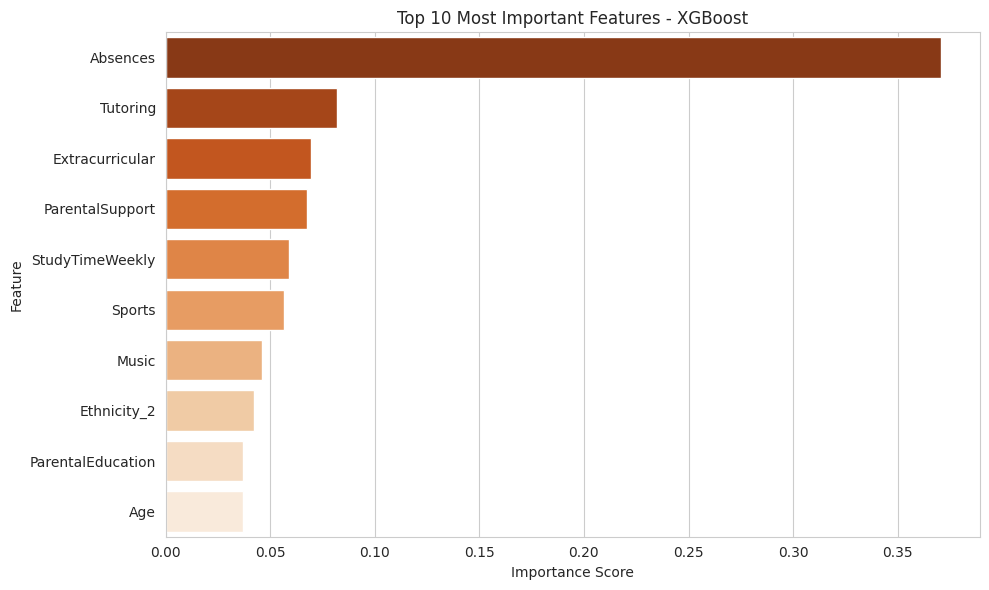

In [20]:
# XGBoost feature importance

trained_xgb_model = xgb_pipeline.named_steps["model"]

feature_names = (
    xgb_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": trained_xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="Oranges_r",
    legend=False
)

plt.title("Top 10 Most Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Step 13 Results (XGBoost Feature Importance)

Feature importance analysis was performed using the final XGBoost model to identify which variables contributed most to predicting academic risk.

The results show that **Absences** was the most important feature, with an importance score of **0.3708**. This score was much higher than the scores of the other variables, indicating that attendance played a major role in the model's predictions.

The next most important features were:

1. **Tutoring** (0.0818)
2. **Extracurricular Participation** (0.0694)
3. **Parental Support** (0.0675)
4. **Study Time Weekly** (0.0590)
5. **Sports Participation** (0.0567)

These results suggest that attendance, academic support, and student engagement are closely associated with academic risk in this dataset.

Several demographic variables, including age, gender, parental education, and ethnicity indicators, had lower importance scores than attendance and engagement-related features. This suggests that the model relied more heavily on behavioral and support-related factors when making predictions.

It is important to note that feature importance reflects the relationships learned by the model and does not prove that a factor causes academic success or failure. Instead, the results highlight which variables were most useful for prediction.

Overall, attendance was the strongest predictor of academic risk, while tutoring, parental support, study time, extracurricular activities, and sports participation also played meaningful roles in the model's predictions. These findings may help educators better understand the factors associated with academic risk and identify areas for further investigation.


# 14. Hyperparameter Tuning of XGBoost

After comparing the three models, XGBoost was selected as the best-performing model in the project.

Although the baseline XGBoost model produced strong results, its performance may be improved by adjusting its hyperparameters.

Hyperparameter tuning tests different model settings to find a combination that produces better results.

In this step, **RandomizedSearchCV** is used with **5-fold stratified cross-validation** to evaluate multiple XGBoost parameter combinations. The goal is to identify a set of parameters that improves model performance while maintaining strong recall.

The best parameter combination found during cross-validation will then be used to train an optimized XGBoost model, which will be compared with the original baseline model.


In [21]:
# Tune XGBoost hyperparameters

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best XGBoost Parameters:")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

print(f"\nBest Cross-Validation ROC-AUC: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Parameters:
model__subsample: 0.9
model__n_estimators: 300
model__max_depth: 3
model__learning_rate: 0.05
model__colsample_bytree: 0.9

Best Cross-Validation ROC-AUC: 0.9253


### Step 14.1 Results (Hyperparameter Tuning of XGBoost)

Hyperparameter tuning was performed using `RandomizedSearchCV` with **5-fold stratified cross-validation** to search for a better set of XGBoost parameters.

The search evaluated **20** randomly selected parameter combinations across different values for tree depth, learning rate, number of trees, subsampling rate, and feature sampling rate. In total, **100 model fits** were completed during the tuning process.

The best parameter combination was:

* **n_estimators:** 300
* **max_depth:** 3
* **learning_rate:** 0.05
* **subsample:** 0.90
* **colsample_bytree:** 0.90

Using these parameters, the model achieved a cross-validation **ROC-AUC of 0.9253**.

Compared with the baseline XGBoost model, the improvement was relatively small. The ROC-AUC increased from **0.9239** to **0.9253**, suggesting that the original model was already performing well before tuning.

The optimized model will be evaluated on the testing dataset to determine whether the tuned parameters improve overall performance.


## 14.2 Optimized XGBoost Evaluation

After identifying the best hyperparameters, the optimized XGBoost model is trained on the full training dataset and evaluated on the testing dataset.

This step compares the optimized model with the baseline XGBoost model to determine whether tuning improved performance.

The model is evaluated using:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

Because the goal of this project is to identify students who may need academic support, special attention is given to recall and false negatives.


Optimized XGBoost Test Performance
--------------------------------------------------
Accuracy : 0.8894
Precision: 0.8931
Recall   : 0.9508
F1-Score : 0.9210
ROC-AUC  : 0.9311

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.76      0.82       154
           1       0.89      0.95      0.92       325

    accuracy                           0.89       479
   macro avg       0.89      0.86      0.87       479
weighted avg       0.89      0.89      0.89       479



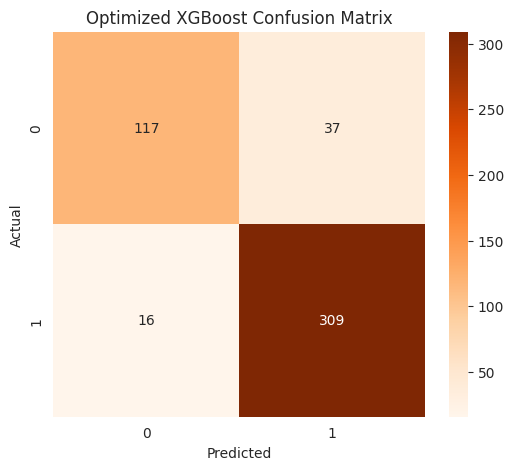

In [22]:
# Evaluate optimized XGBoost model

optimized_xgb_pipeline = random_search.best_estimator_

optimized_xgb_pipeline.fit(X_train, y_train)

y_pred_xgb_optimized = optimized_xgb_pipeline.predict(X_test)
y_prob_xgb_optimized = optimized_xgb_pipeline.predict_proba(X_test)[:, 1]

optimized_xgb_accuracy = accuracy_score(y_test, y_pred_xgb_optimized)
optimized_xgb_precision = precision_score(y_test, y_pred_xgb_optimized)
optimized_xgb_recall = recall_score(y_test, y_pred_xgb_optimized)
optimized_xgb_f1 = f1_score(y_test, y_pred_xgb_optimized)
optimized_xgb_auc = roc_auc_score(y_test, y_prob_xgb_optimized)

print("Optimized XGBoost Test Performance")
print("-" * 50)
print(f"Accuracy : {optimized_xgb_accuracy:.4f}")
print(f"Precision: {optimized_xgb_precision:.4f}")
print(f"Recall   : {optimized_xgb_recall:.4f}")
print(f"F1-Score : {optimized_xgb_f1:.4f}")
print(f"ROC-AUC  : {optimized_xgb_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb_optimized))

# Confusion matrix
cm_xgb_optimized = confusion_matrix(y_test, y_pred_xgb_optimized)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb_optimized,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Optimized XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 14.2 Results (Optimized XGBoost Evaluation)

The optimized XGBoost model was evaluated on the testing dataset after hyperparameter tuning.

The model achieved an accuracy of **88.94%**, a precision score of **89.31%**, a recall score of **95.08%**, an F1-score of **92.10%**, and a ROC-AUC score of **93.11%**.

The confusion matrix shows that:

* **309** at-risk students were correctly identified (True Positives).
* **117** not-at-risk students were correctly identified (True Negatives).
* **37** not-at-risk students were incorrectly classified as at risk (False Positives).
* **16** at-risk students were incorrectly classified as not at risk (False Negatives).

Recall remains one of the most important metrics in this project because the goal is to identify students who may need academic support. The optimized model correctly identified more than **95%** of at-risk students and reduced the number of false negatives to **16**, the lowest value observed in this project.

Compared with the baseline XGBoost model, the optimized version produced small improvements in recall, F1-score, and ROC-AUC while maintaining the same overall accuracy.

Overall, the optimized XGBoost model achieved the best results in this project and was selected as the final model for feature importance analysis, business recommendations, and deployment planning.


## 14.2.1 Cross-Validation of the Optimized XGBoost Model

After identifying the best hyperparameters through RandomizedSearchCV, the optimized XGBoost model is evaluated using the same 5-fold stratified cross-validation framework used for the baseline models.

This additional validation step provides a consistent comparison between the optimized and baseline models and helps us to assess whether the tuned model improves generalization performance across multiple training-validation splits.

In [23]:
# Cross-validation for optimized XGBoost model

optimized_xgb_pipeline = random_search.best_estimator_

optimized_xgb_cv_results = cross_validate(
    optimized_xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics,
    return_train_score=False
)

optimized_xgb_cv_summary = {
    "CV Accuracy": optimized_xgb_cv_results["test_accuracy"].mean(),
    "CV Precision": optimized_xgb_cv_results["test_precision"].mean(),
    "CV Recall": optimized_xgb_cv_results["test_recall"].mean(),
    "CV F1-Score": optimized_xgb_cv_results["test_f1"].mean(),
    "CV ROC-AUC": optimized_xgb_cv_results["test_roc_auc"].mean()
}

print("Optimized XGBoost Cross-Validation Results")
print("-" * 50)

for metric, value in optimized_xgb_cv_summary.items():
    print(f"{metric}: {value:.4f}")

Optimized XGBoost Cross-Validation Results
--------------------------------------------------
CV Accuracy: 0.8928
CV Precision: 0.9023
CV Recall: 0.9446
CV F1-Score: 0.9229
CV ROC-AUC: 0.9253


### Step 14.2.1: Results (Optimized XGBoost Cross-Validation)

The optimized XGBoost model was evaluated using 5-fold stratified cross-validation on the training dataset.

The model achieved an average cross-validation accuracy of **89.28%**, precision of **90.23%**, recall of **94.46%**, F1-score of **92.29%**, and ROC-AUC of **92.53%**.

Compared with the baseline XGBoost model, the optimized model showed small but consistent improvements across most evaluation metrics. Recall increased from **94.23%** to **94.46%**, F1-score increased from **92.14%** to **92.29%**, and ROC-AUC improved from **92.39%** to **92.53%**.

The results suggest that hyperparameter tuning slightly improved the model's ability to identify at-risk students while maintaining strong overall predictive performance. The optimized model continues to demonstrate good generalization across different training-validation splits and remains the strongest-performing model evaluated in this project.

## 14.3 Baseline vs Optimized XGBoost Comparison

After hyperparameter tuning, the optimized XGBoost model is compared with the original XGBoost model.

Both models are evaluated using the same testing dataset and compared using the following metrics:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

Because the goal of this project is to identify students who may need academic support, particular attention is given to recall and false negatives.

The purpose of this comparison is to determine whether hyperparameter tuning improved model performance and whether the optimized model should be selected as the final model.


,Metric,Baseline XGBoost,Optimized XGBoost
0,Accuracy,0.8894,0.8894
1,Precision,0.8953,0.8931
2,Recall,0.9477,0.9508
3,F1-Score,0.9208,0.9210
4,ROC-AUC,0.9294,0.9311



Performance Improvements
----------------------------------------
Recall Improvement : 0.0031
F1 Improvement     : 0.0002
ROC-AUC Improvement: 0.0018


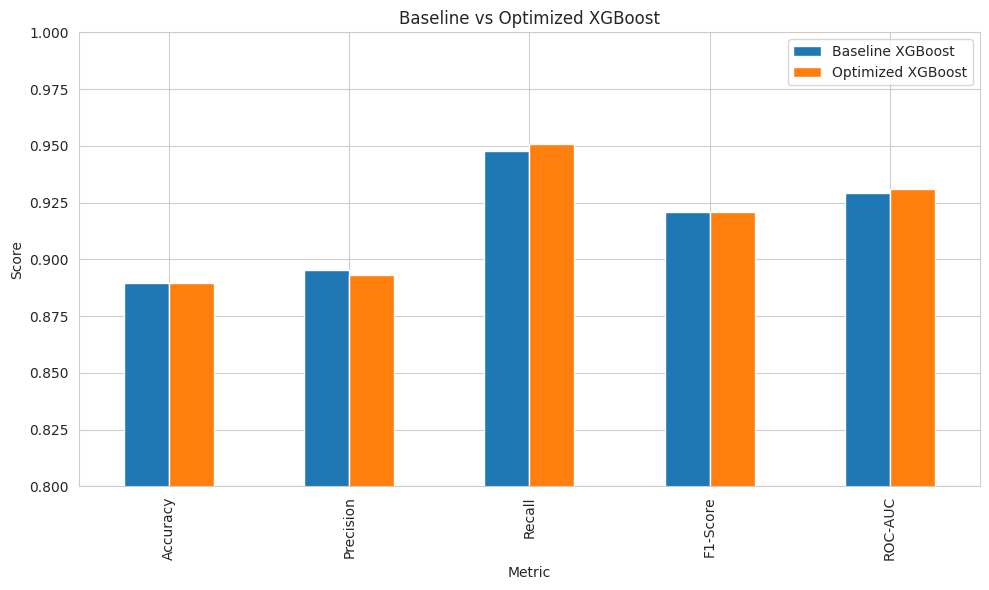

In [24]:
# Compare baseline and optimized XGBoost models

comparison_xgb = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_auc
    ],
    "Optimized XGBoost": [
        optimized_xgb_accuracy,
        optimized_xgb_precision,
        optimized_xgb_recall,
        optimized_xgb_f1,
        optimized_xgb_auc
    ]
})

comparison_xgb = comparison_xgb.round(4)

display(comparison_xgb)

print("\nPerformance Improvements")
print("-" * 40)

print(f"Recall Improvement : {optimized_xgb_recall - xgb_recall:.4f}")
print(f"F1 Improvement     : {optimized_xgb_f1 - xgb_f1:.4f}")
print(f"ROC-AUC Improvement: {optimized_xgb_auc - xgb_auc:.4f}")

plot_df = comparison_xgb.set_index("Metric")

plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Optimized XGBoost")
plt.ylabel("Score")
plt.ylim(0.80, 1.00)

plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Step 14.3 Results (Baseline vs Optimized XGBoost Comparison)

The comparison between the baseline XGBoost model and the optimized XGBoost model shows that hyperparameter tuning resulted in small improvements across several evaluation metrics.

The optimized model maintained the same accuracy (**88.94%**) while slightly improving recall, F1-score, and ROC-AUC. Recall increased from **94.77%** to **95.08%**, F1-score increased from **92.08%** to **92.10%**, and ROC-AUC increased from **92.94%** to **93.11%**.

The performance improvements were relatively small, with a recall increase of **0.31 percentage points**, an F1-score increase of **0.02 percentage points**, and a ROC-AUC increase of **0.18 percentage points**.

The optimized model also reduced the number of false negatives from **17** to **16**, meaning that one additional at-risk student was correctly identified.

Although the improvements are modest, they were consistent across the key evaluation metrics used in this project. The optimized model performed slightly better than the baseline model while maintaining the same overall accuracy.

Based on these results, the optimized XGBoost model was selected as the final model for the remainder of the project.


# 15. Final Model Summary

After evaluating the Decision Tree, Random Forest, baseline XGBoost, and optimized XGBoost models, the optimized XGBoost model was selected as the final model for this project.

The selection was based on both cross-validation results and testing performance. Particular attention was given to recall, F1-score, ROC-AUC, and the number of false negatives because the goal of this project is to identify students who may need academic support.

The optimized XGBoost model achieved the best overall results among the models evaluated. It provided the highest recall, the strongest ROC-AUC score, and the fewest false negatives, making it the preferred model for predicting academic risk.


In [25]:
# Final model summary

print("Selected Model: Optimized XGBoost")

print("\nCross-Validation Results")
print(f"Accuracy : {optimized_xgb_cv_summary['CV Accuracy']:.4f}")
print(f"Precision: {optimized_xgb_cv_summary['CV Precision']:.4f}")
print(f"Recall   : {optimized_xgb_cv_summary['CV Recall']:.4f}")
print(f"F1-Score : {optimized_xgb_cv_summary['CV F1-Score']:.4f}")
print(f"ROC-AUC  : {optimized_xgb_cv_summary['CV ROC-AUC']:.4f}")

print("\nTest Results")
print(f"Accuracy : {optimized_xgb_accuracy:.4f}")
print(f"Precision: {optimized_xgb_precision:.4f}")
print(f"Recall   : {optimized_xgb_recall:.4f}")
print(f"F1-Score : {optimized_xgb_f1:.4f}")
print(f"ROC-AUC  : {optimized_xgb_auc:.4f}")

print("\nWhy this model was selected:")
print("- Highest recall")
print("- Highest F1-score")
print("- Highest ROC-AUC")
print("- Fewest false negatives")
print("- Strong overall performance")

Selected Model: Optimized XGBoost

Cross-Validation Results
Accuracy : 0.8928
Precision: 0.9023
Recall   : 0.9446
F1-Score : 0.9229
ROC-AUC  : 0.9253

Test Results
Accuracy : 0.8894
Precision: 0.8931
Recall   : 0.9508
F1-Score : 0.9210
ROC-AUC  : 0.9311

Why this model was selected:
- Highest recall
- Highest F1-score
- Highest ROC-AUC
- Fewest false negatives
- Strong overall performance


### Step 15 Results (Final Model Summary)

The optimized XGBoost model was selected as the final model for this project after comparing the Decision Tree, Random Forest, baseline XGBoost, and optimized XGBoost models.

During **5-fold stratified cross-validation**, the optimized model achieved an average accuracy of **89.28%**, precision of **90.23%**, recall of **94.46%**, F1-score of **92.29%**, and ROC-AUC of **92.53%**. These results were consistent across the validation folds and represented the strongest overall cross-validation performance among the models evaluated in this project.

The testing results showed similarly strong performance:

* Accuracy: **88.94%**
* Precision: **89.31%**
* Recall: **95.08%**
* F1-Score: **92.10%**
* ROC-AUC: **93.11%**

The model correctly identified more than **95%** of at-risk students and produced only **16 false negatives**, the lowest number among all evaluated models.

Recall was one of the most important metrics in this project because the goal was to identify students who may need academic support. The low number of false negatives means that fewer at-risk students were missed by the model.

The close agreement between the cross-validation and testing results suggests that the model generalizes well and is unlikely to be substantially overfitting the training data.

Based on both the cross-validation and testing results, the optimized XGBoost model achieved the best overall performance and was selected as the final model for the remainder of the project.

# Step 16: Business Recommendations

The results of this project suggest that machine learning may be useful for identifying students who could benefit from additional academic support. The optimized XGBoost model correctly identified more than 95% of at-risk students and may help schools recognize students who need attention earlier in the academic term.

The feature importance analysis showed that **Absences** was the most important predictor of academic risk. This finding suggests that attendance may be an important indicator for monitoring student success. Schools may benefit from tracking attendance patterns and reviewing cases where students begin missing classes more frequently.

Other important features included **Tutoring**, **Extracurricular Participation**, **Parental Support**, **Study Time Weekly**, and **Sports Participation**. These factors were associated with academic risk in the dataset and may provide useful information when identifying students who could benefit from additional support.

The model could be used as a decision-support tool to help counselors, teachers, and administrators prioritize student reviews. Rather than replacing existing support processes, the model can provide an additional source of information when determining which students may need academic assistance.

Because demographic and support-related variables are included in the dataset, schools should regularly review model performance across different student groups. Monitoring recall, false positives, and false negatives across demographic categories can help identify potential fairness concerns.

It is important to note that the results of this project identify patterns in the data and do not prove cause-and-effect relationships. For example, while tutoring and extracurricular participation were associated with lower academic risk, the model cannot determine whether these factors directly improve academic outcomes.

Overall, the findings suggest that attendance, student engagement, and support-related factors are useful indicators of academic risk. Machine learning models such as XGBoost may help educational institutions identify students who need additional attention and support earlier than traditional approaches alone.


# Step 17: Deployment Strategy

The optimized XGBoost model could be deployed as part of a student early-warning system to help identify students who may need additional academic support.

In a real-world setting, information such as attendance records, study time, parental support, tutoring participation, and extracurricular involvement could be collected from existing school information systems. The same preprocessing steps used during model development would then be applied to incoming data before generating predictions.

After preprocessing, the model would produce a probability score indicating the likelihood that a student is academically at risk. Students whose scores exceed a selected threshold could be flagged for review by teachers, counselors, or administrators.

The model achieved strong results during both cross-validation and testing, including a recall rate above 95%. These results suggest that the model may be useful for identifying students who need additional attention. However, the model was evaluated using a single dataset and should be tested further before being used in a real educational environment.

The model should be used as a decision-support tool rather than a replacement for professional judgment. Predictions should be reviewed alongside teacher observations, counselor recommendations, academic records, and other relevant information before any action is taken.

A practical deployment process would include regular updates to student data, periodic model retraining, and ongoing monitoring of model performance. If prediction quality declines over time, the model should be retrained using more recent data.

Schools should also monitor model performance across different demographic groups to help identify potential fairness issues. In addition, student data should be handled according to applicable privacy policies and educational regulations, with access limited to authorized personnel.

Overall, the model may help schools identify students who could benefit from additional support earlier in the academic process. By combining predictive analytics with educator expertise, schools may be able to make more informed decisions about student support and intervention efforts.


## Step 17.1: Deployment Considerations

The proposed deployment would be a **batch prediction system** rather than a real-time application. The model could run once per week using updated student information from the school's student information system.

Because the system would run on a weekly schedule, low-latency prediction is not required. The model does not need to return results instantly, as long as updated risk scores are available for counselors and administrators before student support meetings.

The model could be hosted on a school district server or a secure cloud environment such as AWS, Azure, or Google Cloud. Since the dataset is tabular and the model is relatively lightweight, the expected computing cost would be low, especially if predictions are generated only once per week.

Access to prediction results should be limited to authorized staff, such as counselors, teachers, academic advisors, and administrators. Students should not be automatically labeled or penalized based on the prediction score.

This deployment approach is designed to support proactive student intervention rather than automated decision-making. The system provides risk predictions that can help prioritize student support efforts, while final decisions remain the responsibility of educators and administrators.

# Step 18: Project Conclusion & Limitations

## Conclusion

The goal of this project was to develop a machine learning model capable of identifying students who may be academically at risk and could benefit from additional support.

The project began with data exploration, feature analysis, and the creation of a binary target variable representing student risk status. To prevent target leakage, GPA and GradeClass were excluded from model training because they are directly related to academic outcomes and would not be available as predictors in a real early-warning system.

After data preparation and preprocessing, three supervised learning models were developed and evaluated: Decision Tree, Random Forest, and XGBoost. Model performance was assessed using 5-fold stratified cross-validation on the training dataset and final evaluation on the testing dataset. Multiple evaluation metrics were used, including accuracy, precision, recall, F1-score, and ROC-AUC. Because the goal of the project was to identify students who may need academic support, particular attention was given to recall and false negatives.

Among the models evaluated, XGBoost produced the best overall results and was further improved through hyperparameter tuning using RandomizedSearchCV. The optimized XGBoost model achieved an accuracy of **88.94%**, a precision of **89.31%**, a recall of **95.08%**, an F1-score of **92.10%**, and a ROC-AUC score of **93.11%** on the testing dataset. The model also produced only **16 false negatives**, the lowest number among all evaluated models.

Feature importance analysis showed that **Absences** was the most important predictor of academic risk, followed by tutoring participation, extracurricular involvement, parental support, study time, and sports participation. These results suggest that attendance, engagement, and support-related factors are closely associated with academic risk in this dataset.

The results of this project suggest that machine learning may be useful for helping schools identify students who could benefit from additional academic support. However, model predictions should be used alongside educator expertise, counselor recommendations, and other relevant student information rather than as a replacement for professional judgment.

## Limitations

Several limitations should be considered when interpreting the results of this project.

First, the analysis was conducted using a single dataset and a random train-test split. Although the optimized XGBoost model achieved strong results, performance may differ when applied to students from other schools, districts, geographic regions, or future academic years.

Second, feature importance scores indicate associations between variables and academic risk, but they do not establish causation. For example, the model identified tutoring participation and extracurricular involvement as important predictors, but this does not mean that increasing tutoring or extracurricular activities alone will directly reduce academic risk.

Third, the project relied on the variables available in the dataset. Additional factors such as socioeconomic conditions, course difficulty, teacher interactions, mental health indicators, and longitudinal academic history may improve predictive performance if available.

Fourth, the improvements achieved through hyperparameter tuning were relatively small. The optimized XGBoost model improved recall and reduced false negatives, but the differences compared with the baseline XGBoost model were modest.

Finally, machine learning predictions should not be used as the sole basis for intervention decisions. Student success is influenced by many factors that may not be captured in a dataset, and professional judgment remains essential when determining appropriate support strategies.

Future work could explore additional student behavioral and academic variables, alternative machine learning algorithms, fairness analysis, explainable AI methods, and longitudinal student performance data.

This project developed a machine learning model capable of identifying academically at-risk students. The optimized XGBoost model achieved strong predictive performance and high recall, making it a promising tool for supporting student early-warning efforts.
